# IaC Generation Analysis: Deployability and Error Taxonomy
This notebook analyzes the results of LLM-generated Infrastructure-as-Code (IaC) templates. The analysis is heavily inspired by:
1. **Deployability-Centric Infrastructure-as-Code Generation**: Focusing on iterative refinement, pass rates, and stage-specific failures.
2. **IaC Generation with LLMs: An Error Taxonomy**: Focusing on categorizing error patterns and tracking generation accuracy/coverage.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Set plotting style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_context("notebook", font_scale=1.1)

# Load the dataset
# file_path = "./Result/iterative_openrouter/qwen/qwen3-235b-a22b-thinking-2507_results_9pm28Feb.csv"
file_path = "./result/arcee-ai/trinity-large-preview:free_results_030326.csv"
df = pd.read_csv(file_path)

# Display basic info
display(df.info())
display(df.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53 entries, 0 to 52
Data columns (total 12 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   row_number              53 non-null     int64  
 1   prompt                  53 non-null     object 
 2   ground_truth_path       53 non-null     object 
 3   final_template_path     53 non-null     object 
 4   success                 53 non-null     bool   
 5   failure_reason          29 non-null     object 
 6   error_message           29 non-null     object 
 7   failed_at_stage         29 non-null     object 
 8   total_iterations        53 non-null     int64  
 9   highest_feedback_level  43 non-null     object 
 10  coverage_percentage     24 non-null     float64
 11  accuracy_percentage     24 non-null     float64
dtypes: bool(1), float64(2), int64(2), object(7)
memory usage: 4.7+ KB


None

,row_number,prompt,ground_truth_path,final_template_path,success,failure_reason,error_message,failed_at_stage,total_iterations,highest_feedback_level,coverage_percentage,accuracy_percentage
0,0,We need a CloudFormation template that creates...,../Data/groud_truth/template/sqs_easy.yaml,llm_generated_data/template/iterative/deepseek...,True,NaN,NaN,NaN,1,NaN,100.0,100.0
1,1,We need a CloudFormation template that creates...,../Data/groud_truth/template/sns_easy.yaml,llm_generated_data/template/iterative/deepseek...,True,NaN,NaN,NaN,1,NaN,100.0,50.0
2,2,We need a CloudFormation template that creates...,../Data/groud_truth/template/s3_easy.yaml,llm_generated_data/template/iterative/deepseek...,True,NaN,NaN,NaN,1,NaN,100.0,100.0
3,3,We need a CloudFormation template that creates...,../Data/groud_truth/template/s3_webhost_and_de...,llm_generated_data/template/iterative/deepseek...,True,NaN,NaN,NaN,5,moderate,100.0,100.0
4,4,We need a CloudFormation template that creates...,../Data/groud_truth/template/ec2_easy.yaml,llm_generated_data/template/iterative/deepseek...,False,max_stage_error_attempts_exceeded,An error occurred (ValidationError) when calli...,deployment,12,moderate,NaN,NaN


## 1. Overall Deployability & Success Metrics
In the "Deployability-Centric" paper, standard correctness is not enough; the ultimate metric is whether the code successfully deploys. Here we calculate the overall deployment success rate, as well as the average structural accuracy and coverage of the generated templates.

Total Scenarios Evaluated: 53
Overall Deployment Success Rate: 45.28%


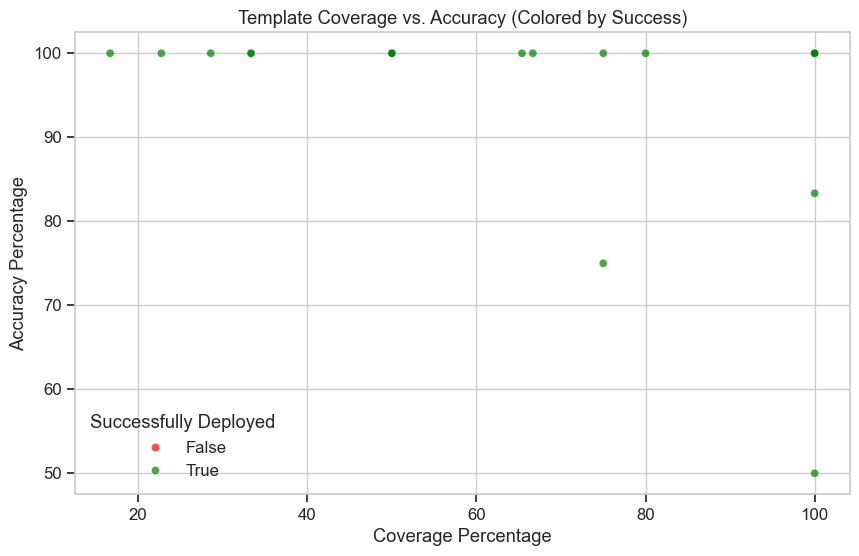

,coverage_percentage,accuracy_percentage
success,,
False,NaN,NaN
True,72.778472,96.180556


In [4]:
# Calculate basic success rates
total_samples = len(df)
successful_deployments = df['success'].sum()
overall_success_rate = (successful_deployments / total_samples) * 100

print(f"Total Scenarios Evaluated: {total_samples}")
print(f"Overall Deployment Success Rate: {overall_success_rate:.2f}%")

# Plot Coverage vs Accuracy for Successful vs Failed deployments
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df, 
    x='coverage_percentage', 
    y='accuracy_percentage', 
    hue='success', 
    palette={True: 'green', False: 'red'},
    alpha=0.7
)
plt.title('Template Coverage vs. Accuracy (Colored by Success)')
plt.xlabel('Coverage Percentage')
plt.ylabel('Accuracy Percentage')
plt.legend(title='Successfully Deployed')
plt.show()

# Mean metrics
mean_metrics = df.groupby('success')[['coverage_percentage', 'accuracy_percentage']].mean()
display(mean_metrics)

## 2. Iteration Analysis (Fail, Learn, Refine)
LLMs often fail on the first attempt but can self-correct when provided with feedback from compilers, validators, or live deployment engines. 
Here, we analyze how many iterations it took to succeed. We calculate the **Pass@1** metric (success on iteration 1) versus **Pass@K** (success after K iterations).

Pass@1 Rate (First Attempt Success): 18.87%
Improvement through Iteration: 26.42%


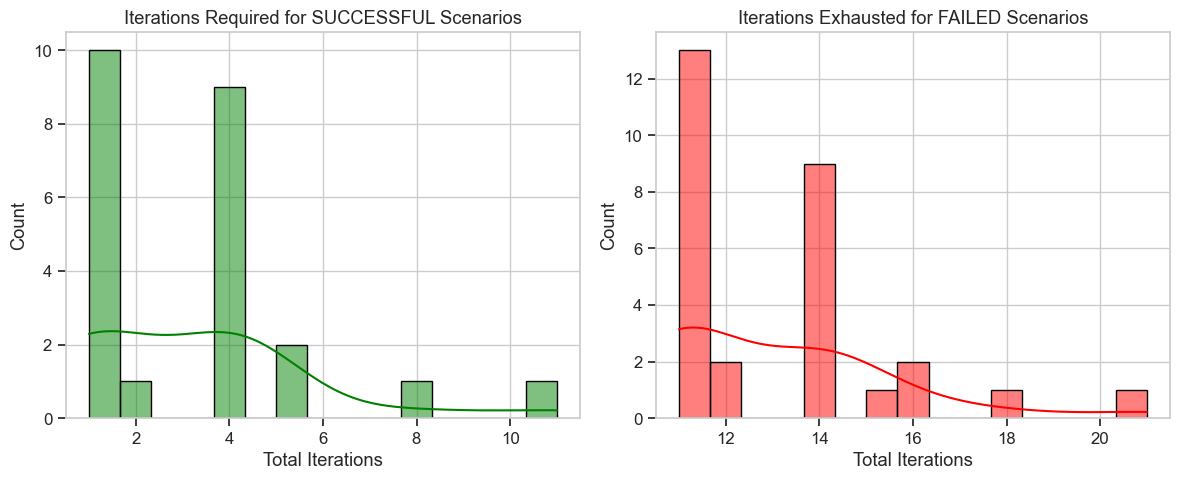

In [6]:
# Calculate Pass@1 (Success on first iteration) vs Pass@Total
# Assuming total_iterations == 1 means it passed on the first try without needing corrections
pass_at_1 = len(df[(df['success'] == True) & (df['total_iterations'] == 1)])
pass_at_1_rate = (pass_at_1 / total_samples) * 100

print(f"Pass@1 Rate (First Attempt Success): {pass_at_1_rate:.2f}%")
print(f"Improvement through Iteration: {overall_success_rate - pass_at_1_rate:.2f}%")

# Distribution of Iterations
plt.figure(figsize=(12, 5))

# Plot 1: Iterations for Successful runs
plt.subplot(1, 2, 1)
sns.histplot(df[df['success'] == True]['total_iterations'], bins=15, color='green', kde=True)
plt.title('Iterations Required for SUCCESSFUL Scenarios')
plt.xlabel('Total Iterations')

# Plot 2: Iterations for Failed runs (likely hit max attempts)
plt.subplot(1, 2, 2)
sns.histplot(df[df['success'] == False]['total_iterations'], bins=15, color='red', kde=True)
plt.title('Iterations Exhausted for FAILED Scenarios')
plt.xlabel('Total Iterations')

plt.tight_layout()
plt.show()

## 3. Pipeline Stage Analysis
The DevOps simulation paper divides failures into stages: 
1. Format/Syntax Validation
2. Security/Policy Checks (Optional depending on your pipeline)
3. Live Deployment / Cloud API Rejection

By looking at `failed_at_stage`, we can see where the LLM struggles the most. Does it write invalid YAML/HCL, or does it write syntactically correct code that the cloud provider rejects?

/var/folders/mr/k47n2bks0fs1y0cmq922vqbh0000gn/T/ipykernel_7235/349793439.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=stage_counts.values, y=stage_counts.index, palette='magma')


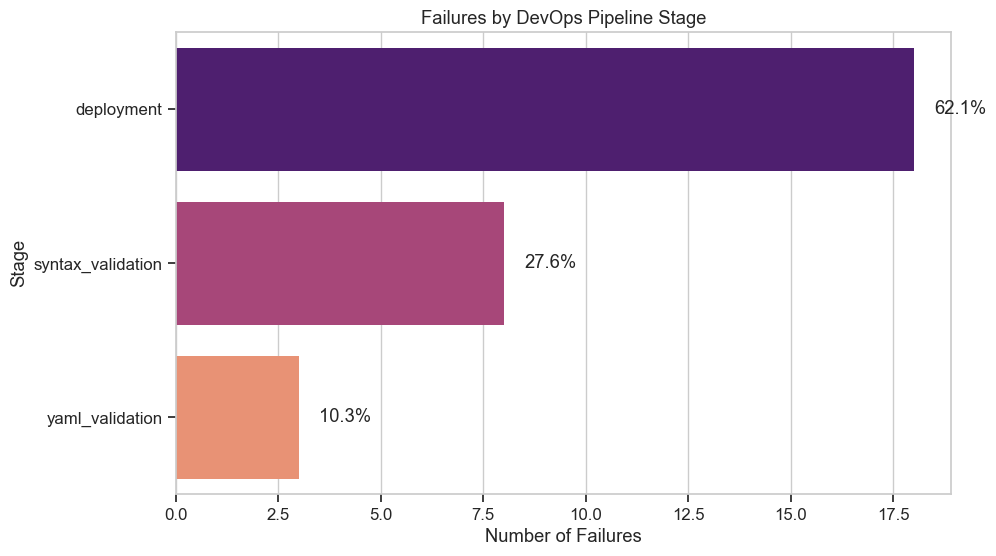

In [8]:
# Filter only failed attempts
failed_df = df[df['success'] == False].copy()

if 'failed_at_stage' in failed_df.columns and failed_df['failed_at_stage'].notna().any():
    plt.figure(figsize=(10, 6))
    
    # Count failures by stage
    stage_counts = failed_df['failed_at_stage'].value_counts()
    
    sns.barplot(x=stage_counts.values, y=stage_counts.index, palette='magma')
    plt.title('Failures by DevOps Pipeline Stage')
    plt.xlabel('Number of Failures')
    plt.ylabel('Stage')
    
    # Add percentage labels
    for i, v in enumerate(stage_counts.values):
        plt.text(v + 0.5, i, f"{(v/len(failed_df)*100):.1f}%", va='center')
        
    plt.show()
else:
    print("Column 'failed_at_stage' is missing or empty in the dataset.")

## 4. Error Taxonomy Analysis
Drawing from the "Error Taxonomy" paper, we categorize the explicit reasons why the code failed (e.g., hallucinated parameters, missing dependencies, permissions errors). 
We will analyze the `failure_reason` and correlate it with the `highest_feedback_level` required.

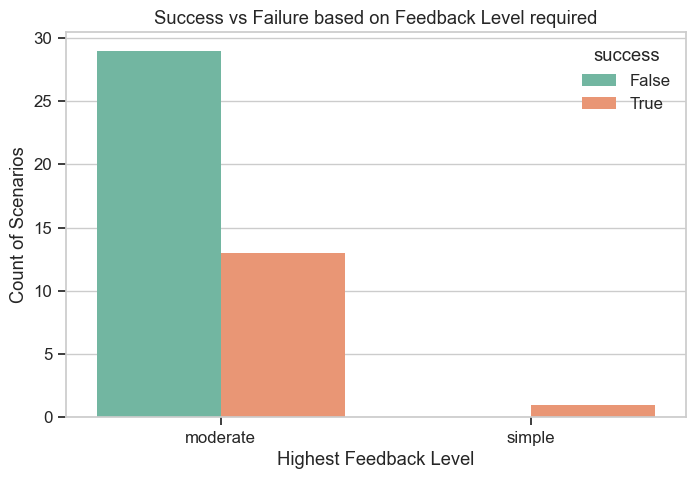

In [10]:
# if 'failure_reason' in failed_df.columns:
#     plt.figure(figsize=(12, 8))
    
#     # Get top 10 most common failure reasons
#     top_failures = failed_df['failure_reason'].value_counts().head(10)
    
#     sns.barplot(x=top_failures.values, y=top_failures.index, palette='rocket')
#     plt.title('Top 10 IaC Generation Error Types (Taxonomy)')
#     plt.xlabel('Frequency')
#     plt.ylabel('Failure Reason')
#     plt.tight_layout()
#     plt.show()
    
#     print("Summary of specific error messages mapping to taxonomy:")
#     # Display a sample of the raw error messages to help you map them to the paper's taxonomy manually
#     if 'error_message' in failed_df.columns:
#         display(failed_df[['failure_reason', 'error_message']].dropna().head(10))

# Analyze highest feedback level
if 'highest_feedback_level' in df.columns:
    plt.figure(figsize=(8, 5))
    sns.countplot(data=df, x='highest_feedback_level', hue='success', palette='Set2')
    plt.title('Success vs Failure based on Feedback Level required')
    plt.xlabel('Highest Feedback Level')
    plt.ylabel('Count of Scenarios')
    plt.show()

## 2b. Pass@k Metrics Table
In the context of iterative refinement (DevOps simulation), **Pass@k** represents the percentage of scenarios that successfully deployed within $k$ attempts. 
- **Pass@1** is the zero-shot/first-try success rate.
- **Pass@K** (where K is the max iteration limit) is the final success rate after the LLM exhausted all its chances to self-correct.

Cumulative Pass@k Success Rates:


,k (Attempts limit),Successful Scenarios,Total Scenarios,Pass@k Rate (%)
0,1,10,53,18.87%
1,2,11,53,20.75%
2,3,11,53,20.75%
3,4,20,53,37.74%
4,5,22,53,41.51%
5,6,22,53,41.51%
6,7,22,53,41.51%
7,8,23,53,43.40%
8,9,23,53,43.40%
9,10,23,53,43.40%


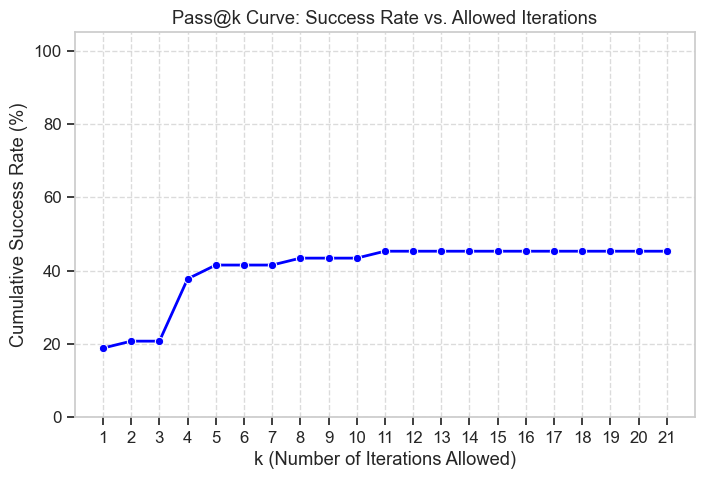

In [12]:
# Calculate max iterations to determine k range
if 'total_iterations' in df.columns:
    max_k = int(df['total_iterations'].max())
    total_samples = len(df)
    
    pass_at_k_records = []
    
    for k in range(1, max_k + 1):
        # Count scenarios that succeeded in k or fewer iterations
        success_within_k = len(df[(df['success'] == True) & (df['total_iterations'] <= k)])
        pass_rate = (success_within_k / total_samples) * 100
        
        pass_at_k_records.append({
            'k (Attempts limit)': k,
            'Successful Scenarios': success_within_k,
            'Total Scenarios': total_samples,
            'Pass@k Rate (%)': pass_rate
        })
    
    # Create DataFrame
    pass_at_k_df = pd.DataFrame(pass_at_k_records)
    
    # Format the percentage column for better display
    display_df = pass_at_k_df.copy()
    display_df['Pass@k Rate (%)'] = display_df['Pass@k Rate (%)'].apply(lambda x: f"{x:.2f}%")
    
    print("Cumulative Pass@k Success Rates:")
    display(display_df)
    
    # Optional: Plot the Pass@k curve
    plt.figure(figsize=(8, 5))
    sns.lineplot(data=pass_at_k_df, x='k (Attempts limit)', y='Pass@k Rate (%)', marker='o', linewidth=2, color='b')
    plt.title('Pass@k Curve: Success Rate vs. Allowed Iterations')
    plt.xlabel('k (Number of Iterations Allowed)')
    plt.ylabel('Cumulative Success Rate (%)')
    plt.xticks(range(1, max_k + 1))
    plt.ylim(0, 105)
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.show()
else:
    print("Column 'total_iterations' not found in dataset.")

## 5. Error Message Keyword Analysis
To understand the underlying causes of deployment failures, we extract the raw `error_message` logs. The errors are tokenized, common stop words and JSON keys are filtered out, and we visualize the most frequently occurring terms. This helps pinpoint whether failures are driven by specific cloud providers, missing parameters, IAM roles, etc.

/var/folders/mr/k47n2bks0fs1y0cmq922vqbh0000gn/T/ipykernel_7235/917113681.py:56: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(counts), y=list(keywords), palette='crest')


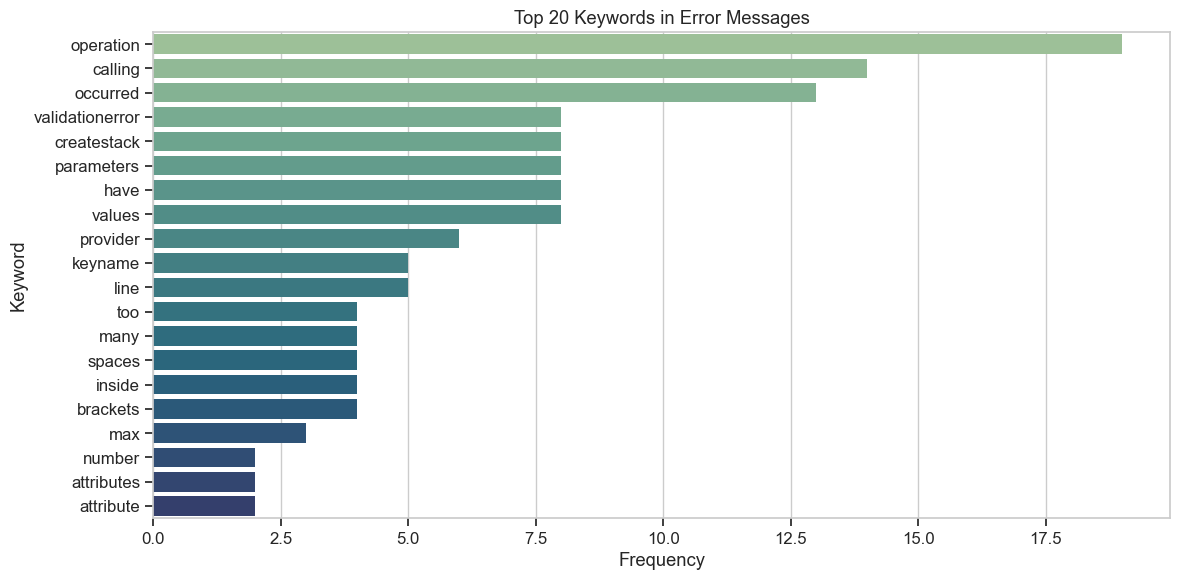

In [14]:
import ast
import re
from collections import Counter

# Filter for failed deployments that have error messages
failed_df = df[df['success'] == False].copy()

if 'error_message' in failed_df.columns:
    error_texts = failed_df['error_message'].dropna().astype(str)
    
    # Helper function to extract text if it's stored as a stringified list of dicts
    def extract_reasons(msg):
        text_content = ""
        try:
            # Safely evaluate the stringified list
            parsed = ast.literal_eval(msg)
            if isinstance(parsed, list):
                for item in parsed:
                    if isinstance(item, dict) and 'reason' in item:
                        reason = item['reason']
                        if reason != 'N/A': # Ignore empty reasons
                            text_content += " " + str(reason)
            else:
                text_content = str(msg)
        except (ValueError, SyntaxError):
            # Fallback to treating it as a raw string if it's not a list of dicts
            text_content = str(msg)
            
        return text_content.lower()

    # Extract all text
    combined_text = " ".join(error_texts.apply(extract_reasons))
    
    # Tokenize words using regex (keeping only alphabetical strings)
    words = re.findall(r'[a-z]+', combined_text)
    
    # Define stop words to ignore (standard English + domain/structural noise)
    stop_words = set([
        'the', 'is', 'in', 'to', 'for', 'of', 'and', 'with', 'on', 'not', 'be', 'an', 'as', 
        'at', 'it', 'this', 'that', 'from', 'by', 'are', 'or', 'which', 'error', 'failed',
        'resource', 'reason', 'n', 'a', 'validation', 'stack', 'creation', 'during',
        'properties', 'template', 'provided', 'invalid', 'already', 'exists', 'must', 'while', 'when'
    ])
    
    # Filter words and keep those with length > 2
    meaningful_words = [w for w in words if w not in stop_words and len(w) > 2]
    
    # Get top 20 keywords
    word_counts = Counter(meaningful_words)
    top_keywords = word_counts.most_common(20)
    
    if top_keywords:
        keywords, counts = zip(*top_keywords)
        
        plt.figure(figsize=(12, 6))
        sns.barplot(x=list(counts), y=list(keywords), palette='crest')
        plt.title('Top 20 Keywords in Error Messages')
        plt.xlabel('Frequency')
        plt.ylabel('Keyword')
        plt.tight_layout()
        plt.show()
    else:
        print("No meaningful keywords found to plot.")
else:
    print("Column 'error_message' not found in dataset.")